<div style="background:linear-gradient(135deg,#78350f 0%,#d97706 55%,#f59e0b 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fde68a;font-weight:700;text-transform:uppercase">Chapter 51 · Case Study</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Sales Calls to First Win: the Geometric ☎️</div>
  <div style="font-size:15px;color:#fff7ed;max-width:740px;line-height:1.6">How many calls until a rep lands the first sale? That waiting time is the geometric distribution. We fit the success rate, compare lead segments, and use the memoryless property to plan staffing.</div>
  <div style="margin-top:16px;font-size:13px;color:#fed7aa">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup &amp; data

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
AMBER="#d97706"; TEAL="#0d9488"; INK="#1a2138"; GRID="#e6e9f2"; PINK="#db2777"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
try:    df = pd.read_csv("../../data/telemarketing_sales_outreach.csv")
except FileNotFoundError: df = pd.read_csv(BASE+"telemarketing_sales_outreach.csv")
print("loaded:", df.shape)
df.head()

loaded: (1000, 4)


,agent_id,call_date,lead_segment,calls_to_first_success
0,AGT_DOE,2026-03-01,Mid-Market,1
1,AGT_JONES,2026-03-01,Mid-Market,5
2,AGT_SMITH,2026-03-01,Mid-Market,8
3,AGT_SMITH,2026-03-01,SMB,18
4,AGT_SMITH,2026-03-01,SMB,2


<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 1 · FIT THE SUCCESS RATE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Mean wait gives p</div>
<div style="color:#4a5578;margin-top:6px">The geometric counts trials up to the first success, PMF (1-p)^(k-1) p. Its mean is 1/p, so the per-call success rate is just one over the average number of calls.</div>
</div>

In [2]:
x = df["calls_to_first_success"]
p = 1/x.mean()
print(f"records           : {len(x):,}")
print(f"mean calls to win  : {x.mean():.3f}")
print(f"per-call rate p = 1/mean = {p:.4f}  ({p:.1%})")
print(f"Geometric mean   = 1/p       = {1/p:.3f}")
print(f"Geometric variance = (1-p)/p^2 = {(1-p)/p**2:.3f}")

records           : 1,000
mean calls to win  : 6.449
per-call rate p = 1/mean = 0.1551  (15.5%)
Geometric mean   = 1/p       = 6.449
Geometric variance = (1-p)/p^2 = 35.141


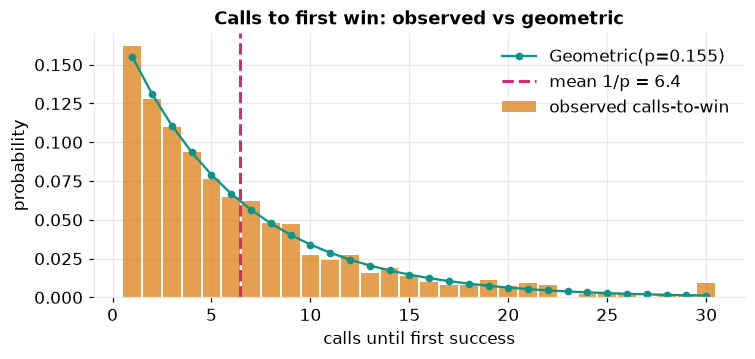

In [3]:
fig,ax=plt.subplots(figsize=(7,3.4))
kmax=30; k=np.arange(1,kmax+1)
obs=x.clip(upper=kmax).value_counts(normalize=True).sort_index()
ax.bar(obs.index,obs.values,color=AMBER,alpha=0.7,width=0.9,label="observed calls-to-win")
ax.plot(k, stats.geom.pmf(k,p),"o-",color=TEAL,ms=4,label=f"Geometric(p={p:.3f})")
ax.axvline(1/p,color=PINK,ls="--",lw=2,label=f"mean 1/p = {1/p:.1f}")
ax.set_xlabel("calls until first success"); ax.set_ylabel("probability"); ax.set_title("Calls to first win: observed vs geometric"); ax.legend()
plt.tight_layout(); plt.show()

In [4]:
# Formal goodness-of-fit: chi-square on observed vs expected counts.
# Rule of thumb: merge adjacent bins so every EXPECTED count is at least 5, then
# chi-square = sum((obs-exp)**2 / exp), with df = (bins - 1 - number of fitted parameters).
def chisq_gof(counts, pmf, n_params):
    N = len(counts); kmax = int(counts.max())
    obs = np.array([(counts == k).sum() for k in range(kmax + 1)], float)
    exp = np.array([N * pmf(k) for k in range(kmax + 1)], float)
    obs = np.append(obs, 0.0); exp = np.append(exp, N - exp.sum())   # tail bin for k > kmax
    mo, me, co, ce = [], [], 0.0, 0.0
    for o, e in zip(obs, exp):
        co += o; ce += e
        if ce >= 5:
            mo.append(co); me.append(ce); co = ce = 0.0
    if ce > 0 and mo:
        mo[-1] += co; me[-1] += ce
    mo, me = np.array(mo), np.array(me)
    chi2 = ((mo - me) ** 2 / me).sum(); dof = len(mo) - 1 - n_params
    return chi2, dof, stats.chi2.sf(chi2, dof)

chi2, dof, pval = chisq_gof(x.values, lambda k: stats.geom.pmf(k, p), 1)
print(f"Chi-square goodness-of-fit: chi2 = {chi2:.2f}, df = {dof}, p = {pval:.3f}  -> "
      + ("cannot reject the fit (Geometric is a good model)" if pval > 0.05 else "reject: not Geometric"))

Chi-square goodness-of-fit: chi2 = 12.57, df = 23, p = 0.961  -> cannot reject the fit (Geometric is a good model)


To validate rather than assume, a **chi-square goodness-of-fit** test compares the observed call-counts to a Geometric(p) (rare tail bins merged so expected counts stay at least 5): chi-square = 12.6 on 23 df, p = 0.96, so we comfortably cannot reject the Geometric fit.

The data is the classic geometric shape: success on the **first** call is the single most likely outcome, but a long right tail of stubborn leads drags the average wait to about **6.5 calls**. One rate p &#8776; 0.155 describes the whole funnel.

<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 2 · WHICH SEGMENT IS EASIEST?</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A rate per lead type</div>
<div style="color:#4a5578;margin-top:6px">Each lead segment is its own geometric process. Comparing 1/p across segments shows where reps land sales fastest, a direct read on lead quality.</div>
</div>

In [5]:
seg = df.groupby("lead_segment")["calls_to_first_success"].agg(["mean","count"])
seg["p_per_call"] = 1/seg["mean"]
print(seg.sort_values("mean").round(4))

                mean  count  p_per_call
lead_segment                           
SMB           6.2733    494      0.1594
Mid-Market    6.3706    402      0.1570
Enterprise    7.5865    104      0.1318


Segments with a smaller average wait have a higher per-call success rate p, easier leads. The spread across segments is exactly the kind of efficiency signal a sales manager acts on: route reps toward the high-p segments, or invest training where p is low.

<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 3 · MEMORYLESS: THE SUNK-COST TRAP</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Past calls do not change the future</div>
<div style="color:#4a5578;margin-top:6px">The geometric is MEMORYLESS: after k failures, the expected remaining calls is still 1/p. Simulating confirms it, and it warns against the gambler's fallacy of 'we are due for a yes'.</div>
</div>

In [6]:
rng = np.random.default_rng(51)
sim = rng.geometric(p, size=2_000_000)
print(f"overall expected remaining wait        = {1/p:.2f} calls")
cond = sim[sim>5] - 5            # already failed 5 times: how many MORE calls?
print(f"expected remaining AFTER 5 failures    = {cond.mean():.2f} calls   (still ~1/p, memoryless)")
print(f"P(win within 5 calls)  = {1-(1-p)**5:.3f}")
print(f"P(win within 10 calls) = {1-(1-p)**10:.3f}")

overall expected remaining wait        = 6.45 calls
expected remaining AFTER 5 failures    = 6.46 calls   (still ~1/p, memoryless)
P(win within 5 calls)  = 0.569
P(win within 10 calls) = 0.815


Whether a rep is on call 1 or call 6, the expected number of remaining calls to a sale is the same **6.5**: the geometric has no memory. There is a **57%** chance of a win within 5 calls and **82%** within 10. The lesson for managers is hard but useful: a string of rejections does not make the next yes any more "due", so set call budgets from p, not from a hot or cold streak.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ Case closed</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">Calls to the first sale are geometric. We fit p &#8776; 0.155 (mean wait 6.5), compared lead segments by their per-call rate, and used the memoryless property to set honest call budgets. The single rate p turns a noisy sales floor into a plan.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>